## Joining and aggregating Data Streams
### Step 1 : Initialize Spark Session 

In [1]:
import os
os.environ['PYSPARK_SUBMIT_ARGS'] = '--packages org.apache.spark:spark-streaming-kafka-0-10_2.12:3.0.0,org.apache.spark:spark-sql-kafka-0-10_2.12:3.0.0 pyspark-shell'
from pyspark import SparkConf
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *

conf = SparkConf().setAppName("Spark Stream Join DEMO").setMaster("local[*]")
spark = SparkSession.builder.config(conf = conf).getOrCreate()

### Step 2 : Load Two Data Streams from Kafka

In [2]:
climate_stream = spark \
  .readStream \
  .format("kafka") \
  .option("kafka.bootstrap.servers", "127.0.0.1:9092") \
  .option("subscribe", "Climate") \
  .option("startingOffsets", "latest")\
  .load()

fire_stream = spark \
  .readStream \
  .format("kafka") \
  .option("kafka.bootstrap.servers", "127.0.0.1:9092") \
  .option("subscribe", "Terra") \
  .option("startingOffsets", "latest")\
  .load()

### Step 3 : Transform the data

1. Convert to key & value
2. Split values based on comma
3. Extract each value
4. Add timestampt and watermarking
    - A watermark delay of “10 seconds” guarantees that the engine will never drop any data that is less than 10 seconds delayed. But data delayed by more than 10 seconds may or may not get processed.
    
***But why do we want to define watermarking?***


In [3]:
from pyspark.sql.types import *

climate_df = climate_stream \
    .selectExpr(
        "CAST(key AS STRING) AS key_climate", 
        "CAST(value AS STRING) AS value_climate") \
    .withColumn(
        "value_climate_split", F.split(F.col("value_climate"), ",")) \
    .select(
        "key_climate",
        F.element_at("value_climate_split", 1).astype(FloatType()).alias("latitude"), 
        F.element_at("value_climate_split", 2).astype(FloatType()).alias("longitude"), 
        F.element_at(F.col("value_climate_split"), 3).astype(FloatType()).alias("air_temperature_celcius"), 
        F.element_at(F.col("value_climate_split"), 4).astype(FloatType()).alias("relative_humidity"), 
        F.element_at(F.col("value_climate_split"), 5).astype(FloatType()).alias("wind_speed_knots")
    ) \
    .withColumn('climate_ts', F.current_timestamp()) \
    .withWatermark('climate_ts', "10 seconds")

fire_df = fire_stream \
    .selectExpr(
        "CAST(key AS STRING) AS key_fire", 
        "CAST(value AS STRING) AS value_fire") \
    .withColumn(
        "value_fire_split", 
        F.split(F.col("value_fire"), ",")) \
    .select(
        "key_fire",
        F.element_at("value_fire_split", 1).astype(FloatType()).alias("latitude"), 
        F.element_at("value_fire_split", 2).astype(FloatType()).alias("longitude"), 
        F.element_at(F.col("value_fire_split"), 3).astype(FloatType()).alias("power"), 
        F.element_at(F.col("value_fire_split"), 4).astype(FloatType()).alias("confidence"), 
        F.element_at(F.col("value_fire_split"), 5).astype(FloatType()).alias("surface_temperature_celcius")
    ) \
    .withColumn('fire_ts', F.current_timestamp()) \
    .withWatermark('fire_ts', "10 seconds")



### Step 4: Joining the Stream on the key and timestamp

An artificial scenario - joining based on the geohash location and the timestamp (when fire_ts is within 1 minute after climate_ts) 

<a class="anchor" id="lab-task-1"></a>
<div style="background:rgba(0,109,174,0.2);padding:10px;border-radius:4px"><strong style="color:#FF5555">1. Lab Task: </strong> 
Write the join condition below with matching geohash and timestamp (when fire_ts is after climate_ts not more than 1 minute)
</div>

In [ ]:

joined_df = climate_df.join(
    fire_df,
    F.expr(???),
    "inner"
) \
    .select(
        climate_df.key_climate, climate_df.climate_ts, 
        climate_df.latitude, climate_df.longitude, 
        fire_df.key_fire, fire_df.fire_ts)


### Step 5 : Write the stream to output sink

In [7]:

# Start running the query that prints the running counts to the console
join_sink = joined_df \
    .writeStream \
    .outputMode("Append")\
    .format("console") \
    .option("truncate","false")\
    .start()

In the console, you should be able to see the joined output.

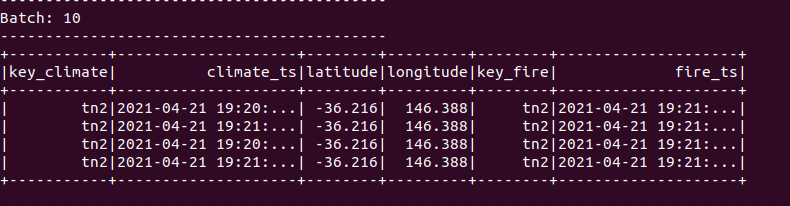

In [11]:
join_sink.stop()

### Step 6 : Aggregate the stream based on time

<a class="anchor" id="lab-task-1"></a>
<div style="background:rgba(0,109,174,0.2);padding:10px;border-radius:4px"><strong style="color:#FF5555">2. Lab Task: </strong> 
Write the code to get the count in a window of 1 minute, with the window sliding interval to 30 seconds. 
</div>

In [ ]:
by_1min_count = joined_df \
    .groupby(F.window(???, ???, ???)) \
    .agg(???)

aggregate_sink = by_1min_count \
    .writeStream \
    .outputMode("append") \
    .format("console") \
    .option("truncate","false")\
    .start()

In [12]:
aggregate_sink.stop()

NameError: name 'aggregate_sink' is not defined